In [ ]:
# core
import os
import warnings
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# stats
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

# preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# model selection
from sklearn.model_selection import train_test_split, cross_val_score

# classification models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression

# metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# optional imbalance handling
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
from pathlib import Path

base_path = Path("E:/FraudPulse/data/raw/credit_risk")
a1 = pd.read_excel(base_path / "case_study1.xlsx")
a2 = pd.read_excel(base_path / "case_study2.xlsx")

In [4]:
#making copies of the datasets to work with
df1 = a1.copy()
df2 = a2.copy()

In [5]:
print("case_study1 shape:", a1.shape)
print("case_study2 shape:", a2.shape)

display(a1.head())
display(a2.head())

print("case_study1 columns:", a1.columns.tolist())
print("case_study2 columns:", a2.columns.tolist())

case_study1 shape: (51336, 26)
case_study2 shape: (51336, 62)


,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,0,0,0.00,0.0,0,0,0,0,1,0,4,1,4,0,72,18
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,1,0,1.00,0.0,0,0,0,1,0,0,0,0,1,0,7,7
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,2,0,0.25,0.0,1,1,0,6,1,0,0,2,6,0,47,2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,1,0,1.00,0.0,1,0,0,0,0,0,0,0,1,1,5,5
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,0,0,0.00,0.0,0,1,0,0,0,0,0,3,0,2,131,32


,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_utilization,CC_Flag,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549,35,15,11,29,29,0,0,0,-99999,-99999,0,0,21,5,11,0,0,0,0,0,0,0,0,0,29,6,0,0,0,6,0,0,566,0,0,0,Married,12TH,48,M,51000,114,0.200,0.0,0.798,-99999.0,0,0.798,1,0.0,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,47,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,209,1,0,0,Single,GRADUATE,23,F,19000,50,1.000,0.0,0.370,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,302,11,3,9,25,25,1,9,8,25,25,0,0,10,5,10,0,0,0,0,0,0,0,0,0,25,4,0,0,0,0,0,0,587,0,0,0,Married,SSC,40,M,18,191,1.000,0.5,0.585,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,-99999,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,5,4,5,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,Married,SSC,34,M,10000,246,1.000,1.0,0.990,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,583,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,53,4,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3951,0,0,0,Married,POST-GRADUATE,48,M,15000,75,0.333,0.0,0.000,-99999.0,0,-99999.000,0,0.0,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


case_study1 columns: ['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl', 'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL']
case_study2 columns: ['PROSPECTID', 'time_since_recent_payment', 'time_since_first_deliquency', 'time_since_recent_deliquency', 'num_times_delinquent', 'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts', 'num_lss_12mts', 'recent_level_of_deliq', 'tot_en

In [6]:
#checking info of the datasets
print("\nInfo of df1:")
print(df1.info())
print("\nInfo of df2:")
print(df2.info())


Info of df1:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PROSPECTID            51336 non-null  int64  
 1   Total_TL              51336 non-null  int64  
 2   Tot_Closed_TL         51336 non-null  int64  
 3   Tot_Active_TL         51336 non-null  int64  
 4   Total_TL_opened_L6M   51336 non-null  int64  
 5   Tot_TL_closed_L6M     51336 non-null  int64  
 6   pct_tl_open_L6M       51336 non-null  float64
 7   pct_tl_closed_L6M     51336 non-null  float64
 8   pct_active_tl         51336 non-null  float64
 9   pct_closed_tl         51336 non-null  float64
 10  Total_TL_opened_L12M  51336 non-null  int64  
 11  Tot_TL_closed_L12M    51336 non-null  int64  
 12  pct_tl_open_L12M      51336 non-null  float64
 13  pct_tl_closed_L12M    51336 non-null  float64
 14  Tot_Missed_Pmnt       51336 non-null  int64  
 15  Auto_

In [7]:
#checking descriptive statistics
print("\nDescriptive statistics of df1:")
print(df1.describe())
print("\nDescriptive statistics of df2:")
print(df2.describe())


Descriptive statistics of df1:
         PROSPECTID      Total_TL  Tot_Closed_TL  Tot_Active_TL  \
count  51336.000000  51336.000000   51336.000000   51336.000000   
mean   25668.500000      4.858598       2.770415       2.088184   
std    14819.571046      7.177116       5.941680       2.290774   
min        1.000000      1.000000       0.000000       0.000000   
25%    12834.750000      1.000000       0.000000       1.000000   
50%    25668.500000      2.000000       1.000000       1.000000   
75%    38502.250000      5.000000       3.000000       3.000000   
max    51336.000000    235.000000     216.000000      47.000000   

       Total_TL_opened_L6M  Tot_TL_closed_L6M  pct_tl_open_L6M  \
count         51336.000000       51336.000000     51336.000000   
mean              0.736754           0.428919         0.184574   
std               1.296717           0.989972         0.297414   
min               0.000000           0.000000         0.000000   
25%               0.000000        

In [8]:
#checking head of datasets
print("\nHead of df1:") 
print(df1.head())
print("\nHead of df2:")
print(df2.head())



Head of df1:
   PROSPECTID  Total_TL  Tot_Closed_TL  Tot_Active_TL  Total_TL_opened_L6M  \
0           1         5              4              1                    0   
1           2         1              0              1                    0   
2           3         8              0              8                    1   
3           4         1              0              1                    1   
4           5         3              2              1                    0   

   Tot_TL_closed_L6M  pct_tl_open_L6M  pct_tl_closed_L6M  pct_active_tl  \
0                  0            0.000                0.0          0.200   
1                  0            0.000                0.0          1.000   
2                  0            0.125                0.0          1.000   
3                  0            1.000                0.0          1.000   
4                  0            0.000                0.0          0.333   

   pct_closed_tl  Total_TL_opened_L12M  Tot_TL_closed_L12M  pct_tl

In [9]:
# Random sample
print(a1.sample(10))
print(a2.sample(10))

       PROSPECTID  Total_TL  Tot_Closed_TL  Tot_Active_TL  \
27937       27938         4              2              2   
11399       11400         1              0              1   
21774       21775         2              0              2   
17087       17088         1              0              1   
47498       47499         1              0              1   
28105       28106         3              2              1   
95             96         2              0              2   
11673       11674         1              0              1   
30173       30174         3              1              2   
6511         6512         4              4              0   

       Total_TL_opened_L6M  Tot_TL_closed_L6M  pct_tl_open_L6M  \
27937                    0                  0              0.0   
11399                    0                  0              0.0   
21774                    0                  0              0.0   
17087                    1                  0              1.0  

In [10]:
def check_missing_data(df, df_name):
    # Calculate NaN counts
    null_counts = df.isnull().sum()
    
    # Calculate placeholder -99999 counts
    placeholder_counts = (df == -99999).sum()
    
    # Total missing (NaN + -99999)
    total_missing = null_counts + placeholder_counts
    
    # Calculate percentage
    percent_missing = (total_missing / len(df)) * 100
    
    # Create a summary DataFrame
    summary = pd.DataFrame({
        'NaN_Count': null_counts,
        'Placeholder_Count': placeholder_counts,
        'Total_Missing': total_missing,
        'Missing_Percentage': percent_missing
    })
    
    # Filter and display only columns with missing data
    summary = summary[summary['Total_Missing'] > 0].sort_values(by='Missing_Percentage', ascending=False)
    
    print(f"\n--- Missing Data Summary for {df_name} ---")
    if summary.empty:
        print("No missing data found!")
    else:
        print(summary)

# Check both DataFrames
check_missing_data(a1, "df1")
check_missing_data(a2, "df2")


--- Missing Data Summary for df1 ---
               NaN_Count  Placeholder_Count  Total_Missing  Missing_Percentage
Age_Oldest_TL          0                 40             40            0.077918
Age_Newest_TL          0                 40             40            0.077918

--- Missing Data Summary for df2 ---
                              NaN_Count  Placeholder_Count  Total_Missing  \
CC_utilization                        0              47636          47636   
PL_utilization                        0              44435          44435   
time_since_recent_deliquency          0              35949          35949   
max_delinquency_level                 0              35949          35949   
time_since_first_deliquency           0              35949          35949   
max_unsec_exposure_inPct              0              23178          23178   
max_deliq_6mts                        0              12890          12890   
max_deliq_12mts                       0              10832          108

In [11]:
#remove nulls
df1 = df1.loc[df1['Age_Oldest_TL']!=-99999]

In [12]:
column_to_be_removed = []
for i in df2.columns:
    if df2.loc[df2[i] == -99999].shape[0] > 10000:
        column_to_be_removed.append(i)

print("Columns to be removed due to high number of nulls:", column_to_be_removed)
        

Columns to be removed due to high number of nulls: ['time_since_first_deliquency', 'time_since_recent_deliquency', 'max_delinquency_level', 'max_deliq_6mts', 'max_deliq_12mts', 'CC_utilization', 'PL_utilization', 'max_unsec_exposure_inPct']


In [13]:
df2=df2.drop(columns=column_to_be_removed, axis=1)    

In [14]:
df2.shape

(51336, 54)

In [15]:
for i in df2.columns:
    df2 = df2.loc[df2[i] != -99999]

In [16]:
df2.shape

(42066, 54)

In [17]:
#checking null values
print("\nNull values in df1:")  
print(df1.isnull().sum())   
print("\nNull values in df2:")
print(df2.isnull().sum())


Null values in df1:
PROSPECTID              0
Total_TL                0
Tot_Closed_TL           0
Tot_Active_TL           0
Total_TL_opened_L6M     0
Tot_TL_closed_L6M       0
pct_tl_open_L6M         0
pct_tl_closed_L6M       0
pct_active_tl           0
pct_closed_tl           0
Total_TL_opened_L12M    0
Tot_TL_closed_L12M      0
pct_tl_open_L12M        0
pct_tl_closed_L12M      0
Tot_Missed_Pmnt         0
Auto_TL                 0
CC_TL                   0
Consumer_TL             0
Gold_TL                 0
Home_TL                 0
PL_TL                   0
Secured_TL              0
Unsecured_TL            0
Other_TL                0
Age_Oldest_TL           0
Age_Newest_TL           0
dtype: int64

Null values in df2:
PROSPECTID                    0
time_since_recent_payment     0
num_times_delinquent          0
max_recent_level_of_deliq     0
num_deliq_6mts                0
num_deliq_12mts               0
num_deliq_6_12mts             0
num_times_30p_dpd             0
num_times_60p

In [18]:
#checking common coluns names
for i in list(df1.columns):
    if i not in df2.columns:
        print(i)

Total_TL
Tot_Closed_TL
Tot_Active_TL
Total_TL_opened_L6M
Tot_TL_closed_L6M
pct_tl_open_L6M
pct_tl_closed_L6M
pct_active_tl
pct_closed_tl
Total_TL_opened_L12M
Tot_TL_closed_L12M
pct_tl_open_L12M
pct_tl_closed_L12M
Tot_Missed_Pmnt
Auto_TL
CC_TL
Consumer_TL
Gold_TL
Home_TL
PL_TL
Secured_TL
Unsecured_TL
Other_TL
Age_Oldest_TL
Age_Newest_TL


In [19]:
#merge the two datasets, inner join so that no nulls are present 
df = pd.merge(df1, df2, how = 'inner', left_on=['PROSPECTID'], right_on=['PROSPECTID'])

In [20]:
import os

# Define the directory path
output_dir = r'E:\FraudPulse\data\interim'

# Create the directory if it does not exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Define the file path
file_path = os.path.join(output_dir, 'merged_credit_data.csv')

# Save the dataframe to a CSV file
df.to_csv(file_path, index=False)

print(f"Data successfully saved at: {file_path}")

Data successfully saved at: E:\FraudPulse\data\interim\merged_credit_data.csv


In [22]:
df = pd.read_csv(r'E:\FraudPulse\data\interim\merged_credit_data.csv')
print("\nShape of merged dataset:", df.shape)


Shape of merged dataset: (42064, 79)


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42064 entries, 0 to 42063
Data columns (total 79 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PROSPECTID                  42064 non-null  int64  
 1   Total_TL                    42064 non-null  int64  
 2   Tot_Closed_TL               42064 non-null  int64  
 3   Tot_Active_TL               42064 non-null  int64  
 4   Total_TL_opened_L6M         42064 non-null  int64  
 5   Tot_TL_closed_L6M           42064 non-null  int64  
 6   pct_tl_open_L6M             42064 non-null  float64
 7   pct_tl_closed_L6M           42064 non-null  float64
 8   pct_active_tl               42064 non-null  float64
 9   pct_closed_tl               42064 non-null  float64
 10  Total_TL_opened_L12M        42064 non-null  int64  
 11  Tot_TL_closed_L12M          42064 non-null  int64  
 12  pct_tl_open_L12M            42064 non-null  float64
 13  pct_tl_closed_L12M          420

In [24]:
df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,time_since_recent_payment,num_times_delinquent,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,0,0,0.00,0.000,0,0,0,0,1,0,4,1,4,0,72,18,549,11,29,0,0,0,0,0,21,5,11,0,0,0,0,0,0,0,0,0,29,6,0,0,0,6,0,0,566,0,0,0,Married,12TH,48,M,51000,114,0.200,0.0,0.798,0,1,0.0,0.0,0.000,0.0,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,1,0,1.00,0.000,0,0,0,1,0,0,0,0,1,0,7,7,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,209,1,0,0,Single,GRADUATE,23,F,19000,50,1.000,0.0,0.370,0,0,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,2,0,0.25,0.000,1,1,0,6,1,0,0,2,6,0,47,2,302,9,25,1,9,8,0,0,10,5,10,0,0,0,0,0,0,0,0,0,25,4,0,0,0,0,0,0,587,0,0,0,Married,SSC,40,M,18,191,1.000,0.5,0.585,0,0,0.0,0.0,0.000,0.0,1,0,ConsumerLoan,others,693,P2
3,5,3,2,1,0,0,0.000,0.0,0.333,0.667,0,0,0.00,0.000,0,1,0,0,0,0,0,3,0,2,131,32,583,0,0,0,0,0,0,0,53,4,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,3951,0,0,0,Married,POST-GRADUATE,48,M,15000,75,0.333,0.0,0.000,0,0,0.0,0.0,0.000,0.0,0,0,AL,AL,753,P1
4,6,6,5,1,0,0,0.000,0.0,0.167,0.833,0,1,0.00,0.167,0,4,0,0,2,0,0,6,0,0,150,17,245,14,270,0,0,0,13,11,5,0,2,3,0,1,0,0,0,0,0,0,26,15,2,0,1,7,3,3,7,6,5,4,Married,12TH,35,M,0,154,0.167,0.0,0.000,0,0,1.0,0.0,0.429,0.0,1,0,ConsumerLoan,PL,668,P3


In [25]:
#checking for null value
df.isna().sum().sum()

0

In [26]:
#check how many columns are categorical
for i in df.columns:
    if df[i].dtype == 'object':
        print(i)

MARITALSTATUS
EDUCATION
GENDER
last_prod_enq2
first_prod_enq2
Approved_Flag


In [27]:
# Checking unique values, their counts and percentages for all categorical columns
cat_cols = ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']

for col in cat_cols:
    print(f"\n--- {col} (Unique Values: {df[col].nunique()}) ---")
    
    # Getting counts and percentages
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    
    # Combining them into a nice table
    summary_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
    print(summary_df)


--- MARITALSTATUS (Unique Values: 2) ---
               Count  Percentage (%)
MARITALSTATUS                       
Married        30886           73.43
Single         11178           26.57

--- EDUCATION (Unique Values: 7) ---
                Count  Percentage (%)
EDUCATION                            
GRADUATE        14140           33.62
12TH            11703           27.82
SSC              7241           17.21
UNDER GRADUATE   4572           10.87
OTHERS           2291            5.45
POST-GRADUATE    1898            4.51
PROFESSIONAL      219            0.52

--- GENDER (Unique Values: 2) ---
        Count  Percentage (%)
GENDER                       
M       37345           88.78
F        4719           11.22

--- last_prod_enq2 (Unique Values: 6) ---
                Count  Percentage (%)
last_prod_enq2                       
ConsumerLoan    16480           39.18
others          13653           32.46
PL               7553           17.96
CC               2195            5.22
AL  

*analysis of categorical data, highlighting the key insights for each parameter:*

* MARITALSTATUS: The dataset is dominated by married individuals, who account for over 73% of the total, indicating that family-oriented applicants are the primary demographic.

* EDUCATION: Education levels are concentrated, with Graduates and 12th-grade pass-outs combined making up over 61% of the applicants, while Professionals represent a very small niche (0.52%).

* GENDER: There is a significant gender imbalance, with approximately 89% of the applicants being male, which suggests the need for caution to avoid gender-based bias in your model.

* last_prod_enq2 & first_prod_enq2: Consumer Loans and 'others' are the most frequent product categories for both first and last enquiries, indicating that these are the entry points for most customers in this portfolio.

* Approved_Flag (Target Variable): The target variable is imbalanced, with 'P2' being the majority class (60.51%), while 'P1', 'P3', and 'P4' are significantly smaller, which will require careful handling (like SMOTE or class weights) during model training.

In [28]:
#values count in categorical columns
for i in df.columns:
    if df[i].dtype == 'object':
        print(f"\nValue counts for column '{i}':")
        print(df[i].value_counts())


Value counts for column 'MARITALSTATUS':
MARITALSTATUS
Married    30886
Single     11178
Name: count, dtype: int64

Value counts for column 'EDUCATION':
EDUCATION
GRADUATE          14140
12TH              11703
SSC                7241
UNDER GRADUATE     4572
OTHERS             2291
POST-GRADUATE      1898
PROFESSIONAL        219
Name: count, dtype: int64

Value counts for column 'GENDER':
GENDER
M    37345
F     4719
Name: count, dtype: int64

Value counts for column 'last_prod_enq2':
last_prod_enq2
ConsumerLoan    16480
others          13653
PL               7553
CC               2195
AL               1353
HL                830
Name: count, dtype: int64

Value counts for column 'first_prod_enq2':
first_prod_enq2
others          20640
ConsumerLoan    11075
PL               4431
AL               2641
CC               1988
HL               1289
Name: count, dtype: int64

Value counts for column 'Approved_Flag':
Approved_Flag
P2    25452
P3     6440
P4     5264
P1     4908
Name: count, d

*analysis of your categorical data, highlighting the key insights for each parameter:* 

* MARITALSTATUS: The dataset is dominated by married individuals, who account for over 73% of the total, indicating that family-oriented applicants are the primary demographic.

* EDUCATION: Education levels are concentrated, with Graduates and 12th-grade pass-outs combined making up over 61% of the applicants, while Professionals represent a very small niche (0.52%).

* GENDER: There is a significant gender imbalance, with approximately 89% of the applicants being male, which suggests the need for caution to avoid gender-based bias in your model.

* last_prod_enq2 & first_prod_enq2: Consumer Loans and 'others' are the most frequent product categories for both first and last enquiries, indicating that these are the entry points for most customers in this portfolio.

* Approved_Flag (Target Variable): The target variable is imbalanced, with 'P2' being the majority class (60.51%), while 'P1', 'P3', and 'P4' are significantly smaller, which will require careful handling (like SMOTE or class weights) during model training.

In [29]:
#chi square test for categorical variables
for i in ['MARITALSTATUS','EDUCATION','GENDER','last_prod_enq2','first_prod_enq2']:
    chi2,pval,_,_=chi2_contingency(pd.crosstab(df[i], df['Approved_Flag']))
    print(i,'---',pval)

MARITALSTATUS --- 3.578180861038862e-233
EDUCATION --- 2.6942265249737532e-30
GENDER --- 1.907936100186563e-05
last_prod_enq2 --- 0.0
first_prod_enq2 --- 7.84997610555419e-287


Chi-Square Test Analysis:
Significance: Since all the P-values are practically zero (much smaller than 0.05), we reject the null hypothesis for every single variable.

Interpretation: This confirms that there is a statistically significant relationship between each of your categorical variables (MARITALSTATUS, EDUCATION, etc.) and the target variable (Approved_Flag).

Conclusion: These categorical features are not random; they have a strong association with the loan approval status. Therefore, all these features are important and should definitely be included in your machine learning model.

<Axes: xlabel='EDUCATION'>

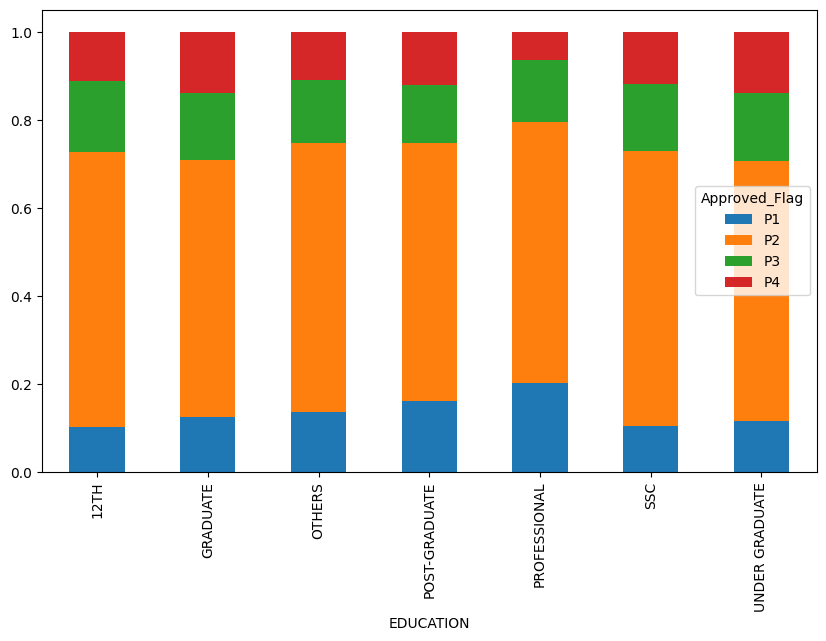

In [30]:
# Crosstab for Education vs Approved_Flag
crosstab = pd.crosstab(df['EDUCATION'], df['Approved_Flag'], normalize='index')
crosstab.plot(kind='bar', stacked=True, figsize=(10,6))

Insights from the Education vs. Approved_Flag Analysis:
Professional Category (Unique Observation): Applicants in the 'PROFESSIONAL' education category show the highest proportion of P1 (Blue) status compared to all other groups. This suggests that applicants with professional degrees may have a distinct or more favorable credit risk profile, which differentiates them from the broader applicant pool.

Consistency (Uniformity): For most other education levels (e.g., 12TH, GRADUATE, SSC, etc.), the proportion of P2 (Orange) status is consistently dominant and relatively uniform. This indicates that, aside from the Professional group, the education level does not have a 'drastic' or highly variable impact on the approval rate.

Distribution of P1 to P4: The P2 (Orange) status remains the majority across all education levels, confirming it as the bank's "Standard Approval Risk Tier." The distribution of P1 and P4 status remains remarkably stable and balanced across every educational background.

In [31]:
# Function to generate categorical summary report text
def generate_categorical_report(df, cat_cols):
    report = []
    report.append("### Categorical Data Executive Summary\n")
    
    for col in cat_cols:
        counts = df[col].value_counts()
        percentages = (df[col].value_counts(normalize=True) * 100).round(2)
        
        # Start the analysis for each column
        report.append(f"**{col} Analysis:**")
        report.append(f"The variable '{col}' has {df[col].nunique()} unique categories.")
        
        # Add the top category details
        top_cat = counts.index[0]
        top_pct = percentages.iloc[0]
        report.append(f"- The dominant category is '{top_cat}' with {top_pct}% of the total records.")
        
        # Add a custom observation
        if len(counts) > 1:
            least_cat = counts.index[-1]
            least_pct = percentages.iloc[-1]
            report.append(f"- The least represented category is '{least_cat}' with only {least_pct}%.")
        
        report.append("") # Empty line for readability
    
    return "\n".join(report)

# Generate and Print the report
cat_cols = ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']
summary_report = generate_categorical_report(df, cat_cols)
print(summary_report)

### Categorical Data Executive Summary

**MARITALSTATUS Analysis:**
The variable 'MARITALSTATUS' has 2 unique categories.
- The dominant category is 'Married' with 73.43% of the total records.
- The least represented category is 'Single' with only 26.57%.

**EDUCATION Analysis:**
The variable 'EDUCATION' has 7 unique categories.
- The dominant category is 'GRADUATE' with 33.62% of the total records.
- The least represented category is 'PROFESSIONAL' with only 0.52%.

**GENDER Analysis:**
The variable 'GENDER' has 2 unique categories.
- The dominant category is 'M' with 88.78% of the total records.
- The least represented category is 'F' with only 11.22%.

**last_prod_enq2 Analysis:**
The variable 'last_prod_enq2' has 6 unique categories.
- The dominant category is 'ConsumerLoan' with 39.18% of the total records.
- The least represented category is 'HL' with only 1.97%.

**first_prod_enq2 Analysis:**
The variable 'first_prod_enq2' has 6 unique categories.
- The dominant category is 'oth

In [32]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate Skewness and IQR (to detect outliers)
stats_df = pd.DataFrame({
    'Skewness': df[num_cols].skew(),
    'Median': df[num_cols].median(),
    'Max': df[num_cols].max()
})

print(stats_df.sort_values(by='Skewness', ascending=False).head(15))

                             Skewness   Median        Max
pct_currentBal_all_TL      136.425967      0.6     6327.5
num_lss_12mts               96.447299      0.0       30.0
num_lss_6mts                96.254908      0.0       12.0
num_lss                     67.951738      0.0       72.0
num_dbt_6mts                59.873882      0.0        6.0
num_dbt_12mts               50.067984      0.0       12.0
num_sub_6mts                45.296119      0.0        5.0
NETMONTHLYINCOME            44.457578  24000.0  2500000.0
num_sub_12mts               34.450688      0.0       12.0
num_dbt                     34.148832      0.0       35.0
num_sub                     21.008687      0.0       41.0
recent_level_of_deliq       12.950406      0.0      900.0
max_recent_level_of_deliq   11.088498      0.0      900.0
Gold_TL                      9.582596      0.0      235.0
CC_TL                        8.874829      0.0       27.0


Executive Summary: Numerical Data & Skewness Analysis
Extreme Right-Skewness (Positive Skew): Almost all listed variables (e.g., pct_currentBal_all_TL, num_lss_12mts, NETMONTHLYINCOME) exhibit extremely high positive skewness values (ranging from ~136 down to 8). This indicates that the data is not normally distributed and is heavily clustered around zero, with a "long tail" extending toward very high values.

Presence of Outliers: High skewness combined with a median of 0.0 for many variables suggests that the majority of the applicant pool has zero or minimal activity in these categories (like missed payments or delinquencies), while a small minority shows extreme behavior. This is typical for credit risk data, where "bad" indicators are rare but impactful.

Income Disparity: The NETMONTHLYINCOME variable shows a significant skew (44.45) with a massive range (up to 2,500,000). The large gap between the median (24,000) and the maximum value confirms that the dataset contains high-income outliers who significantly deviate from the typical applicant.

In [33]:
#VIF for numerical variables
numerical_columns=[]
for i in df.columns:
    if df[i].dtype != 'object'and i not in ['PROSPECTID','Approved_Flag']:
        numerical_columns.append(i)

print("\nNumerical columns for VIF calculation:", numerical_columns)


Numerical columns for VIF calculation: ['Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl', 'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'num_times_delinquent', 'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts', 'num_deliq_6_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts', 'num_lss_12mts', 'recent_level_of_deliq', 'tot_enq', 'CC_enq', 'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m', 'PL_enq_L12m', 'time_since_recent_enq', 'enq_L12m', 'enq_L6m', 'enq_L3m', 'AGE', 'NETMONT

In [34]:
#VIF Sequential Check
vif_data = df[numerical_columns]
total_columns = vif_data.shape[1]
columns_to_be_kept=[]
column_index = 0

for i in range(0,total_columns):
    vif_value = variance_inflation_factor(vif_data,column_index)
    print(column_index,'---',vif_value)

    if vif_value < 6:
        columns_to_be_kept.append(numerical_columns[i])
        column_index += 1
    else:
        vif_data = vif_data.drop(numerical_columns[i], axis=1)

0 --- inf
0 --- inf
0 --- 11.320180023967996
0 --- 8.363698035000336
0 --- 6.520647877790928
0 --- 5.149501618212625
1 --- 2.611111040579735
2 --- inf
2 --- 1788.7926256209232
2 --- 8.601028256477228
2 --- 3.8328007921530785
3 --- 6.099653381646731
3 --- 5.5813520096427585
4 --- 1.9855843530987785
5 --- inf
5 --- 4.809538302819343
6 --- 23.270628983464636
6 --- 30.595522588100053
6 --- 4.384346405965587
7 --- 3.064658415523423
8 --- 2.898639771299251
9 --- 4.377876915347322
10 --- 2.2078535836958433
11 --- 4.916914200506864
12 --- 5.214702030064725
13 --- 3.3861625024231476
14 --- 7.840583309478997
14 --- 5.255034641721438
15 --- inf
15 --- 7.380634506427238
15 --- 1.4210050015175733
16 --- 8.083255010190316
16 --- 1.6241227524040112
17 --- 7.257811920140003
17 --- 15.59624383268298
17 --- 1.8258570471324314
18 --- 1.5080839450032664
19 --- 2.172088834824577
20 --- 2.623397553527229
21 --- 2.2959970812106176
22 --- 7.360578319196439
22 --- 2.160238777310255
23 --- 2.8686288267891467
24

In [35]:
print("\nColumns to be kept after VIF check:", columns_to_be_kept)
print("Number of columns to be kept:", len(columns_to_be_kept))


Columns to be kept after VIF check: ['pct_tl_open_L6M', 'pct_tl_closed_L6M', 'Tot_TL_closed_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'CC_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'max_recent_level_of_deliq', 'num_deliq_6_12mts', 'num_times_60p_dpd', 'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_12mts', 'num_lss', 'num_lss_12mts', 'recent_level_of_deliq', 'CC_enq_L12m', 'PL_enq_L12m', 'time_since_recent_enq', 'enq_L3m', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr', 'pct_currentBal_all_TL', 'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag']
Number of columns to be kept: 39


* Initially there were 72  numerical features out of which only 39 after VIF are selected 

Potential feature clones detected (Correlation > 0.9):


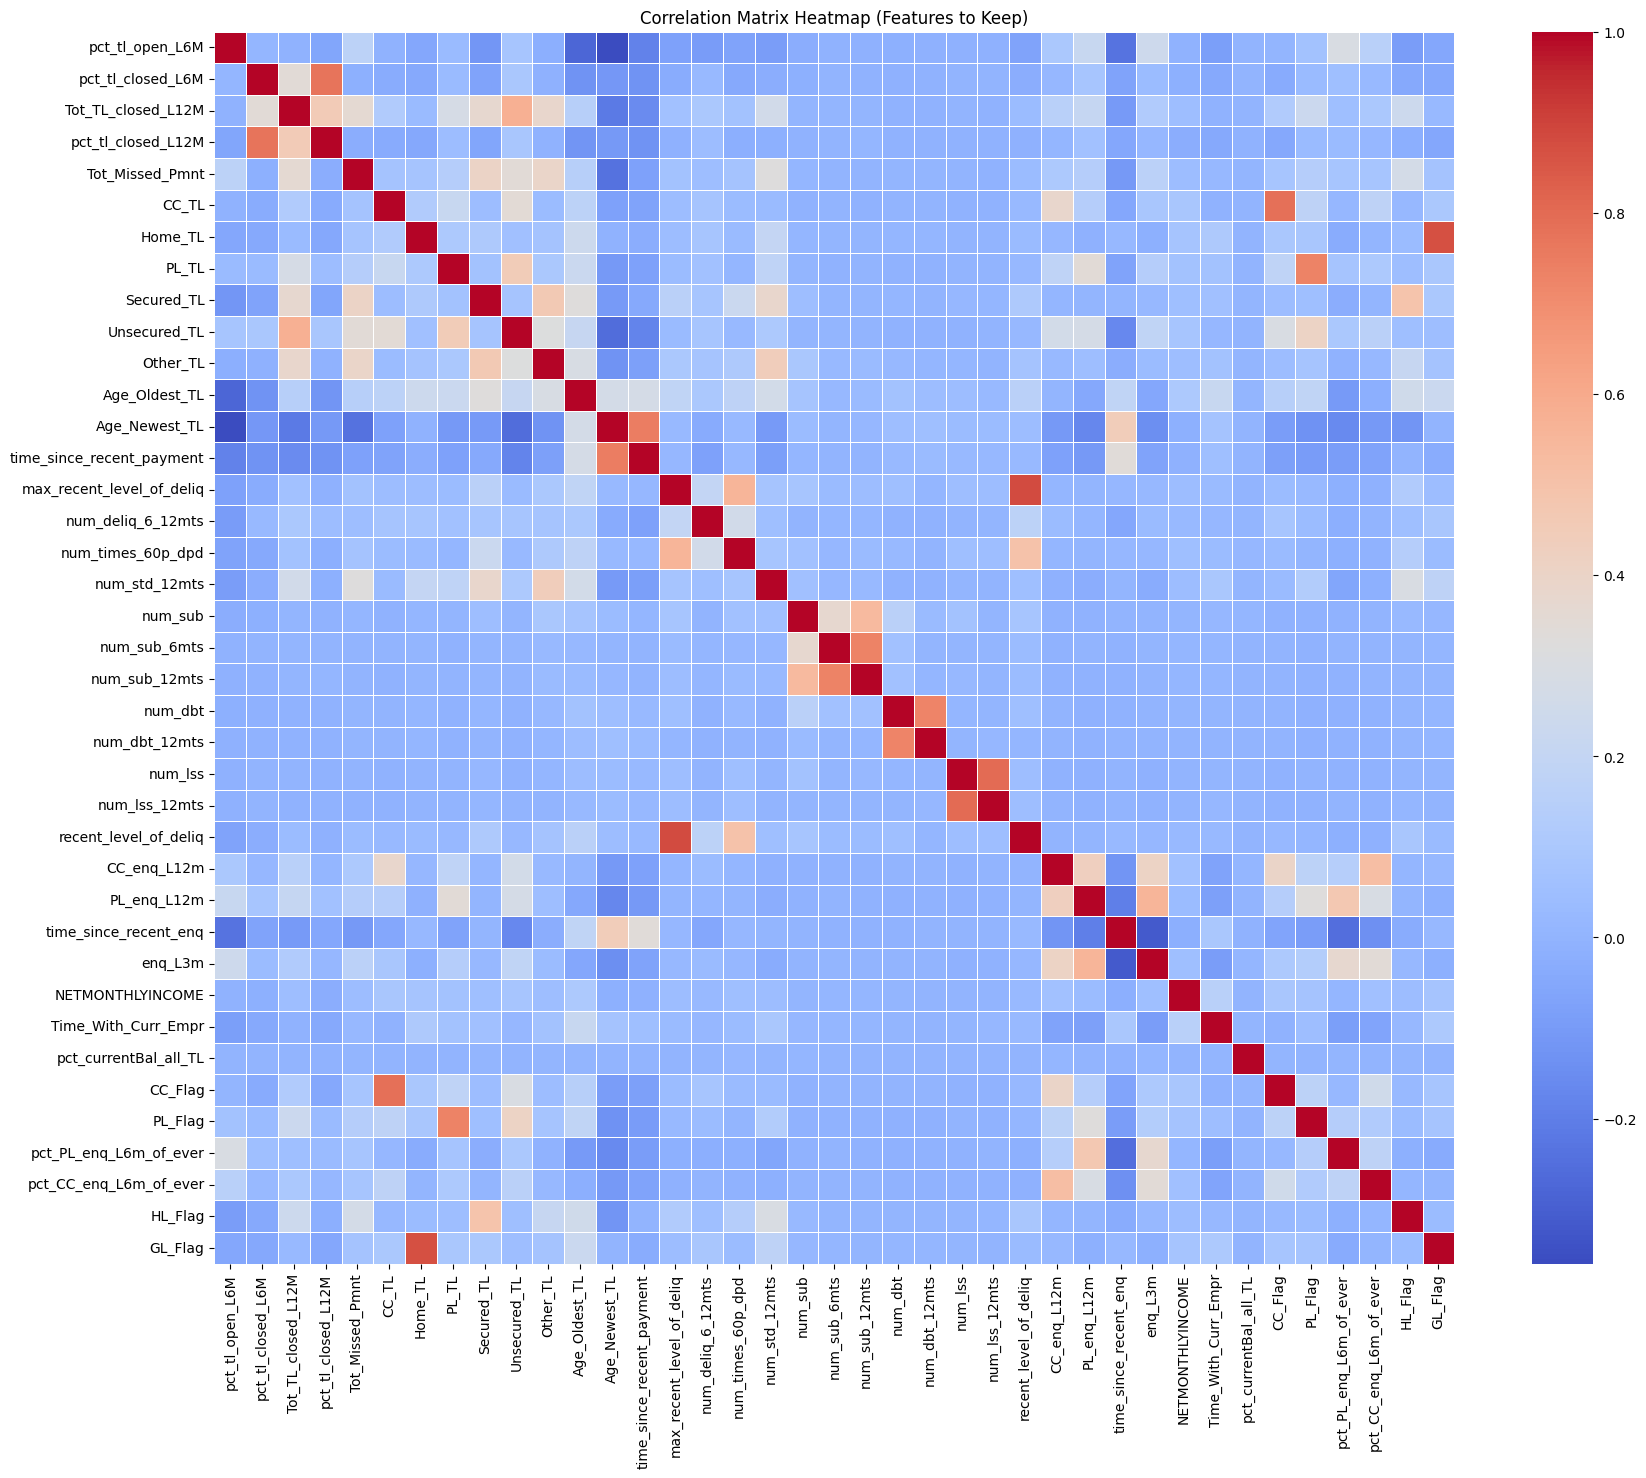

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix for the 39 remaining features
corr_matrix = df[columns_to_be_kept].corr()

# 2. Identify features with high correlation (> 0.9) to detect potential clones
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            col_name = corr_matrix.columns[i]
            pair_name = corr_matrix.columns[j]
            high_corr_pairs.append((col_name, pair_name, corr_matrix.iloc[i, j]))

print("Potential feature clones detected (Correlation > 0.9):")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]} -> Correlation: {pair[2]:.2f}")

# 3. Visualization using Heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Correlation Matrix Heatmap (Features to Keep)")
plt.show()

In [37]:
 #check anova for column_to_be_kept
from scipy.stats import f_oneway

column_to_be_kept_numerical = []

for i in columns_to_be_kept:
    a = list(df[i])
    b = list(df['Approved_Flag'])

    group_P1 = [value for value, group in zip(a, b) if group == 'P1']
    group_P2 = [value for value, group in zip(a, b) if group == 'P2']
    group_P3 = [value for value, group in zip(a, b) if group == 'P3']
    group_P4 = [value for value, group in zip(a, b) if group == 'P4']

    f_statistic, p_value = f_oneway(group_P1, group_P2, group_P3, group_P4)

    if p_value < 0.05:
        column_to_be_kept_numerical.append(i)

In [38]:
print("\nColumns to be kept after anova check:", column_to_be_kept_numerical)
print("Number of columns to be kept:", len(column_to_be_kept_numerical))


Columns to be kept after anova check: ['pct_tl_open_L6M', 'pct_tl_closed_L6M', 'Tot_TL_closed_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'CC_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'max_recent_level_of_deliq', 'num_deliq_6_12mts', 'num_times_60p_dpd', 'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_12mts', 'num_lss', 'recent_level_of_deliq', 'CC_enq_L12m', 'PL_enq_L12m', 'time_since_recent_enq', 'enq_L3m', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr', 'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag']
Number of columns to be kept: 37


In [39]:
df.shape

(42064, 79)

In [40]:
# listing all the final features
features = column_to_be_kept_numerical + ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']
df = df[features + ['Approved_Flag']]

In [41]:
df.shape

(42064, 43)

In [41]:
df['MARITALSTATUS'].unique()    
df['EDUCATION'].unique()
df['GENDER'].unique()
df['last_prod_enq2'].unique()
df['first_prod_enq2'].unique()

array(['PL', 'ConsumerLoan', 'others', 'AL', 'HL', 'CC'], dtype=object)

In [38]:
# Ordinal feature -- EDUCATION
# SSC            : 1
# 12TH           : 2
# GRADUATE       : 3
# UNDER GRADUATE : 3
# POST-GRADUATE  : 4
# OTHERS         : 1
# PROFESSIONAL   : 3


# Others has to be verified by the business end user

In [43]:
df.loc[df['EDUCATION'] == 'SSC',['EDUCATION']]              = 1
df.loc[df['EDUCATION'] == '12TH',['EDUCATION']]             = 2
df.loc[df['EDUCATION'] == 'GRADUATE',['EDUCATION']]         = 3
df.loc[df['EDUCATION'] == 'UNDER GRADUATE',['EDUCATION']]   = 3
df.loc[df['EDUCATION'] == 'POST-GRADUATE',['EDUCATION']]    = 4
df.loc[df['EDUCATION'] == 'OTHERS',['EDUCATION']]           = 1
df.loc[df['EDUCATION'] == 'PROFESSIONAL',['EDUCATION']]     = 3

In [44]:
print(df['EDUCATION'].value_counts())
df['EDUCATION'] = df['EDUCATION'].astype(int)
df.info()

EDUCATION
3    18931
2    11703
1     9532
4     1898
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42064 entries, 0 to 42063
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pct_tl_open_L6M            42064 non-null  float64
 1   pct_tl_closed_L6M          42064 non-null  float64
 2   Tot_TL_closed_L12M         42064 non-null  int64  
 3   pct_tl_closed_L12M         42064 non-null  float64
 4   Tot_Missed_Pmnt            42064 non-null  int64  
 5   CC_TL                      42064 non-null  int64  
 6   Home_TL                    42064 non-null  int64  
 7   PL_TL                      42064 non-null  int64  
 8   Secured_TL                 42064 non-null  int64  
 9   Unsecured_TL               42064 non-null  int64  
 10  Other_TL                   42064 non-null  int64  
 11  Age_Oldest_TL              42064 non-null  int64  
 12  Age_Newest_TL         

In [45]:
df_encoded = pd.get_dummies(df, columns=['MARITALSTATUS','GENDER', 'last_prod_enq2' ,'first_prod_enq2'])

In [46]:
df_encoded.shape

(42064, 55)

In [43]:
df_encoded.head()   

,pct_tl_open_L6M,pct_tl_closed_L6M,Tot_TL_closed_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,CC_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,...,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,first_prod_enq2_AL,first_prod_enq2_CC,first_prod_enq2_ConsumerLoan,first_prod_enq2_HL,first_prod_enq2_PL,first_prod_enq2_others
0,0.000,0.0,0,0.000,0,0,0,4,1,4,...,False,False,True,False,False,False,False,False,True,False
1,0.000,0.0,0,0.000,0,0,0,0,0,1,...,True,False,False,False,False,False,True,False,False,False
2,0.125,0.0,0,0.000,1,0,0,0,2,6,...,True,False,False,False,False,False,False,False,False,True
3,0.000,0.0,0,0.000,0,0,0,0,3,0,...,False,False,False,False,True,False,False,False,False,False
4,0.000,0.0,1,0.167,0,0,0,0,6,0,...,True,False,False,False,False,False,False,False,True,False


In [44]:
df_encoded.info()
k = df_encoded.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42064 entries, 0 to 42063
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   pct_tl_open_L6M               42064 non-null  float64
 1   pct_tl_closed_L6M             42064 non-null  float64
 2   Tot_TL_closed_L12M            42064 non-null  int64  
 3   pct_tl_closed_L12M            42064 non-null  float64
 4   Tot_Missed_Pmnt               42064 non-null  int64  
 5   CC_TL                         42064 non-null  int64  
 6   Home_TL                       42064 non-null  int64  
 7   PL_TL                         42064 non-null  int64  
 8   Secured_TL                    42064 non-null  int64  
 9   Unsecured_TL                  42064 non-null  int64  
 10  Other_TL                      42064 non-null  int64  
 11  Age_Oldest_TL                 42064 non-null  int64  
 12  Age_Newest_TL                 42064 non-null  int64  
 13  t

In [45]:
df_encoded.shape

(42064, 55)

In [46]:
df_encoded.describe()

,pct_tl_open_L6M,pct_tl_closed_L6M,Tot_TL_closed_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,CC_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,...,enq_L3m,NETMONTHLYINCOME,Time_With_Curr_Empr,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,EDUCATION
count,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,...,42064.000000,4.206400e+04,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000,42064.000000
mean,0.179032,0.097783,0.825504,0.160365,0.525746,0.145921,0.076241,0.328000,2.921334,2.341646,...,1.230458,2.692990e+04,110.345783,0.102962,0.193063,0.195497,0.064186,0.252235,0.056580,2.313689
std,0.278043,0.210957,1.537208,0.258831,1.106442,0.549314,0.358582,0.916368,6.379764,3.405397,...,2.069461,2.084300e+04,75.629967,0.303913,0.394707,0.367414,0.225989,0.434300,0.231042,0.871070
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.800000e+04,61.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,2.400000e+04,92.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,0.333000,0.100000,1.000000,0.250000,1.000000,0.000000,0.000000,0.000000,3.000000,3.000000,...,2.000000,3.100000e+04,131.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000
max,1.000000,1.000000,33.000000,1.000000,34.000000,27.000000,10.000000,29.000000,235.000000,55.000000,...,42.000000,2.500000e+06,1020.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000


We will save our data in 2 parts for mal model we will use regular df and for dashbaording we will save it as 'Dashbaord_data.csv'

In [47]:
import os

# Define the target directory and filename
output_dir = r'E:\FraudPulse\data\interim'
file_path = os.path.join(output_dir, 'Dashboard_Data.csv')

# Ensure the directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the encoded dataframe to CSV
df_encoded.to_csv(file_path, index=False)

print(f"Dashboard data successfully saved at: {file_path}")

Dashboard data successfully saved at: E:\FraudPulse\data\interim\Dashboard_Data.csv


In [50]:
#Working on data for Dashbaording 
import pandas as pd
import numpy as np
import os

# 1. Income Bucketing
# Categorizing income into segments to improve dashboard visualization and handle outliers
bins = [0, 25000, 50000, 100000, 2500000]
labels = ['Low Income', 'Medium Income', 'High Income', 'Very High Income']
df_encoded['Income_Bucket'] = pd.cut(df_encoded['NETMONTHLYINCOME'], bins=bins, labels=labels)

# 2. Risk Profiling
# Categorizing customers into risk levels based on delinquency levels
conditions = [
    (df_encoded['recent_level_of_deliq'] == 0),
    (df_encoded['recent_level_of_deliq'] > 0) & (df_encoded['recent_level_of_deliq'] <= 30),
    (df_encoded['recent_level_of_deliq'] > 30)
]
values = ['Low Risk', 'Medium Risk', 'High Risk']
df_encoded['Risk_Profile'] = np.select(conditions, values)

# 3. Approval Analysis Preparation
# Grouping data by 'Approved_Flag' to identify key drivers of loan approval
approval_drivers = df_encoded.groupby('Approved_Flag')[['NETMONTHLYINCOME', 'recent_level_of_deliq', 'Tot_Missed_Pmnt']].mean()

# 4. Save the enhanced data to the specified location
output_dir = r'E:\FraudPulse\data\interim'

# Ensure the directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

file_path = os.path.join(output_dir, 'Dashboard_Data_Enhanced.csv')
df_encoded.to_csv(file_path, index=False)

print("Enhancements completed successfully!")
print(f"Enhanced data saved at: {file_path}")

Enhancements completed successfully!
Enhanced data saved at: E:\FraudPulse\data\interim\Dashboard_Data_Enhanced.csv


In [52]:
#now building dataset for modeling
import os

output_dir = r'E:\FraudPulse\data\interim'
file_path = os.path.join(output_dir, 'Machine_Learning_Dataset.csv')

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

df_encoded.to_csv(file_path, index=False)

print(f"Machine learning dataset saved at: {file_path}")
print(f"Dataset shape: {df_encoded.shape}") 

Machine learning dataset saved at: E:\FraudPulse\data\interim\Machine_Learning_Dataset.csv
Dataset shape: (42064, 57)


In [54]:
#calling data saved formodeling 
df = pd.read_csv(r'E:\FraudPulse\data\interim\Machine_Learning_Dataset.csv')
df.shape

(42064, 57)

In [58]:
# Print all column names
print("All column names:")
print(df.columns.tolist())

# Check whether the output column exists
target_col = 'Approved_Flag'
print(f"\nIs '{target_col}' present in the dataset? ->", target_col in df.columns)

# Print total number of columns
print("\nTotal number of columns:", len(df.columns))

All column names:
['pct_tl_open_L6M', 'pct_tl_closed_L6M', 'Tot_TL_closed_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'CC_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'max_recent_level_of_deliq', 'num_deliq_6_12mts', 'num_times_60p_dpd', 'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_12mts', 'num_lss', 'recent_level_of_deliq', 'CC_enq_L12m', 'PL_enq_L12m', 'time_since_recent_enq', 'enq_L3m', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr', 'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag', 'EDUCATION', 'Approved_Flag', 'MARITALSTATUS_Married', 'MARITALSTATUS_Single', 'GENDER_F', 'GENDER_M', 'last_prod_enq2_AL', 'last_prod_enq2_CC', 'last_prod_enq2_ConsumerLoan', 'last_prod_enq2_HL', 'last_prod_enq2_PL', 'last_prod_enq2_others', 'first_prod_enq2_AL', 'first_prod_enq2_CC', 'first_prod_enq2_ConsumerLoan', 'first_prod_enq2_HL', 'f

In [62]:
# 1. Load the correct ML dataset directly from your interim folder
file_path = r'E:\FraudPulse\data\interim\Machine_Learning_Dataset.csv'
df = pd.read_csv(file_path)

# Separate Numeric and Object/Categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"--- Numeric Columns ({len(numeric_cols)}) ---")
print(numeric_cols)

print(f"\n--- Object/Categorical Columns ({len(object_cols)}) ---")
print(object_cols)


--- Numeric Columns (38) ---
['pct_tl_open_L6M', 'pct_tl_closed_L6M', 'Tot_TL_closed_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'CC_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'max_recent_level_of_deliq', 'num_deliq_6_12mts', 'num_times_60p_dpd', 'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_12mts', 'num_lss', 'recent_level_of_deliq', 'CC_enq_L12m', 'PL_enq_L12m', 'time_since_recent_enq', 'enq_L3m', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr', 'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag', 'EDUCATION']

--- Object/Categorical Columns (3) ---
['Approved_Flag', 'Income_Bucket', 'Risk_Profile']


In [47]:
# Machine Learing model fitting

# Data processing

# 1. Random Forest

y = df_encoded['Approved_Flag']
x = df_encoded. drop ( ['Approved_Flag'], axis = 1 )

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [49]:
rf_classifier = RandomForestClassifier(n_estimators = 200, random_state=42)

In [50]:
rf_classifier.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [51]:
y_pred = rf_classifier.predict(x_test)

In [52]:
accuracy = accuracy_score(y_test, y_pred)
print ()
print(f'Accuracy: {accuracy}')
print ()
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred)


Accuracy: 0.7636990372043266



In [53]:
for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()

Class p1:
Precision: 0.8370457209847597
Recall: 0.7041420118343196
F1 Score: 0.7648634172469202

Class p2:
Precision: 0.7957519116397621
Recall: 0.9282457879088206
F1 Score: 0.856907593778591

Class p3:
Precision: 0.4423380726698262
Recall: 0.21132075471698114
F1 Score: 0.28600612870275793

Class p4:
Precision: 0.7178502879078695
Recall: 0.7269193391642371
F1 Score: 0.7223563495895703



In [54]:
# 2. xgboost

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

xgb_classifier = xgb.XGBClassifier(objective='multi:softmax',  num_class=4)



y = df_encoded['Approved_Flag']
x = df_encoded. drop ( ['Approved_Flag'], axis = 1 )


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)




xgb_classifier.fit(x_train, y_train)
y_pred = xgb_classifier.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print ()
print(f'Accuracy: {accuracy:.2f}')
print ()

precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred)

for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()



Accuracy: 0.77

Class p1:
Precision: 0.8189655172413793
Recall: 0.7495069033530573
F1 Score: 0.7826982492276005

Class p2:
Precision: 0.8218123209169055
Recall: 0.909613478691774
F1 Score: 0.8634866873647568

Class p3:
Precision: 0.46557759626604434
Recall: 0.3011320754716981
F1 Score: 0.36571952337305225

Class p4:
Precision: 0.7279693486590039
Recall: 0.738581146744412
F1 Score: 0.733236854799807



In [55]:
# 3. Decision Tree
from sklearn.tree import DecisionTreeClassifier


y = df_encoded['Approved_Flag']
x = df_encoded. drop ( ['Approved_Flag'], axis = 1 )

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


dt_model = DecisionTreeClassifier(max_depth=20, min_samples_split=10)
dt_model.fit(x_train, y_train)
y_pred = dt_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print ()
print(f"Accuracy: {accuracy:.2f}")
print ()

precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred)

for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()


Accuracy: 0.71

Class p1:
Precision: 0.7211350293542075
Recall: 0.7268244575936884
F1 Score: 0.7239685658153242

Class p2:
Precision: 0.8106163717674509
Recall: 0.8263627353815659
F1 Score: 0.8184138201806046

Class p3:
Precision: 0.3463375796178344
Recall: 0.3283018867924528
F1 Score: 0.33707865168539325

Class p4:
Precision: 0.6471774193548387
Recall: 0.6239067055393586
F1 Score: 0.6353290450272142



* Since Accuracy values of XgBoost is better, Now we will Further Finetune It which will include
* HP Tuning
* Feature Engineering-- Scalling, Feature Engg, Graphs
* see if we cn get better Results

In [56]:
#Hyper parameter Tuning for Xgboost
# Apply standard scaler 

from sklearn.preprocessing import StandardScaler

columns_to_be_scaled = ['Age_Oldest_TL','Age_Newest_TL','time_since_recent_payment',
'max_recent_level_of_deliq','recent_level_of_deliq',
'time_since_recent_enq','NETMONTHLYINCOME','Time_With_Curr_Empr']

for i in columns_to_be_scaled:
    column_data = df_encoded[i].values.reshape(-1, 1)
    scaler = StandardScaler()
    scaled_column = scaler.fit_transform(column_data)
    df_encoded[i] = scaled_column

In [57]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

xgb_classifier = xgb.XGBClassifier(objective='multi:softmax',  num_class=4)



y = df_encoded['Approved_Flag']
x = df_encoded. drop ( ['Approved_Flag'], axis = 1 )


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)




xgb_classifier.fit(x_train, y_train)
y_pred = xgb_classifier.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred)

for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()

Accuracy: 0.77
Class p1:
Precision: 0.8189655172413793
Recall: 0.7495069033530573
F1 Score: 0.7826982492276005

Class p2:
Precision: 0.8218123209169055
Recall: 0.909613478691774
F1 Score: 0.8634866873647568

Class p3:
Precision: 0.46557759626604434
Recall: 0.3011320754716981
F1 Score: 0.36571952337305225

Class p4:
Precision: 0.7279693486590039
Recall: 0.738581146744412
F1 Score: 0.733236854799807



* No improvement in metrices

In [58]:
# Hyperparameter tuning in xgboost
from sklearn.model_selection import GridSearchCV
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)

# Define the XGBClassifier with the initial set of hyperparameters
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=4)

# Define the parameter grid for hyperparameter tuning

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)

# Print the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate the model with the best hyperparameters on the test set
best_model = grid_search.best_estimator_
accuracy = best_model.score(x_test, y_test)
print("Test Accuracy:", accuracy)

Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Test Accuracy: 0.7812908593842862


* Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
* Based on risk appetite of the bank, you will suggest P1,P2,P3,P4 to the business end user

In [59]:
# # Hyperparameter tuning for xgboost (Used in the session)

# Define the hyperparameter grid
param_grid = {
   'colsample_bytree': [0.1, 0.3, 0.5, 0.7, 0.9],
   'learning_rate'   : [0.001, 0.01, 0.1, 1],
   'max_depth'       : [3, 5, 8, 10],
   'alpha'           : [1, 10, 100],
   'n_estimators'    : [10,50,100]
 }

index = 0

answers_grid = {
     'combination'       :[],
     'train_Accuracy'    :[],
     'test_Accuracy'     :[],
     'colsample_bytree'  :[],
     'learning_rate'     :[],
     'max_depth'         :[],
     'alpha'             :[],
     'n_estimators'      :[]

     }

In [60]:
# Loop through each combination of hyperparameters
for colsample_bytree in param_grid['colsample_bytree']:
    for learning_rate in param_grid['learning_rate']:
        for max_depth in param_grid['max_depth']:
            for alpha in param_grid['alpha']:
                for n_estimators in param_grid['n_estimators']:
                    index = index + 1
             
#               # Define and train the XGBoost model
                model = xgb.XGBClassifier(objective='multi:softmax',  
                                            num_class=4,
                                            colsample_bytree = colsample_bytree,                                        
                                            learning_rate = learning_rate,
                                            max_depth = max_depth,
                                            alpha = alpha,
                                            n_estimators = n_estimators)
               
       
                     
                y = df_encoded['Approved_Flag']
                x = df_encoded. drop ( ['Approved_Flag'], axis = 1 )

                label_encoder = LabelEncoder()
                y_encoded = label_encoder.fit_transform(y)

                x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)


                model.fit(x_train, y_train)
  

       
#               # Predict on training and testing sets
                y_pred_train = model.predict(x_train)
                y_pred_test = model.predict(x_test)

                # Calculate train and test results
                train_accuracy = accuracy_score(y_train, y_pred_train)
                test_accuracy  = accuracy_score(y_test , y_pred_test)


                # Include into the lists
                answers_grid['combination'].append(index)
                answers_grid['train_Accuracy'].append(train_accuracy)
                answers_grid['test_Accuracy'].append(test_accuracy)
                answers_grid['colsample_bytree'].append(colsample_bytree)
                answers_grid['learning_rate'].append(learning_rate)
                answers_grid['max_depth'].append(max_depth)
                answers_grid['alpha'].append(alpha)
                answers_grid['n_estimators'].append(n_estimators)


                # Print results for this combination
                print(f"Combination {index}")
                print(f"colsample_bytree: {colsample_bytree}, learning_rate: {learning_rate}, max_depth: {max_depth}, alpha: {alpha}, n_estimators: {n_estimators}")
                print(f"Train Accuracy: {train_accuracy:.2f}")
                print(f"Test Accuracy : {test_accuracy :.2f}")
                print("-" * 30)
       
       





Combination 3
colsample_bytree: 0.1, learning_rate: 0.001, max_depth: 3, alpha: 1, n_estimators: 100
Train Accuracy: 0.61
Test Accuracy : 0.60
------------------------------
Combination 6
colsample_bytree: 0.1, learning_rate: 0.001, max_depth: 3, alpha: 10, n_estimators: 100
Train Accuracy: 0.61
Test Accuracy : 0.60
------------------------------
Combination 9
colsample_bytree: 0.1, learning_rate: 0.001, max_depth: 3, alpha: 100, n_estimators: 100
Train Accuracy: 0.61
Test Accuracy : 0.60
------------------------------
Combination 12
colsample_bytree: 0.1, learning_rate: 0.001, max_depth: 5, alpha: 1, n_estimators: 100
Train Accuracy: 0.61
Test Accuracy : 0.60
------------------------------
Combination 15
colsample_bytree: 0.1, learning_rate: 0.001, max_depth: 5, alpha: 10, n_estimators: 100
Train Accuracy: 0.61
Test Accuracy : 0.60
------------------------------
Combination 18
colsample_bytree: 0.1, learning_rate: 0.001, max_depth: 5, alpha: 100, n_estimators: 100
Train Accuracy: 0.61

In [61]:
model1 = xgb.XGBClassifier(objective='multi:softmax',
                            num_class=4,
                            colsample_bytree = 0.9,                                        
                            learning_rate = 1,
                            max_depth = 3,
                            alpha = 10,
                            n_estimators = 100)

In [62]:
model1.fit(x_train, y_train)

XGBClassifier(alpha=10, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, ...)

In [63]:
#predict for unseen dataset
import pandas as pd
a3 = pd.read_excel(r"E:\FraudPulse\Data\credit_risk\Unseen_Dataset.xlsx")

In [64]:
cols_in_df =list(df.columns)
cols_in_df.pop(42)

'Approved_Flag'

In [65]:
df_unseen = a3[cols_in_df]

df_unseen['MARITALSTATUS'].unique()
df_unseen['EDUCATION'].unique()
df_unseen['GENDER'].unique()
df_unseen['last_prod_enq2'].unique()
df_unseen['first_prod_enq2'].unique()

array(['PL', 'ConsumerLoan', 'others', 'AL', 'HL', 'CC'], dtype=object)

In [66]:
df_unseen.loc[df_unseen['EDUCATION'] == 'SSC',['EDUCATION']]              = 1
df_unseen.loc[df_unseen['EDUCATION'] == '12TH',['EDUCATION']]             = 2
df_unseen.loc[df_unseen['EDUCATION'] == 'GRADUATE',['EDUCATION']]         = 3
df_unseen.loc[df_unseen['EDUCATION'] == 'UNDER GRADUATE',['EDUCATION']]   = 3
df_unseen.loc[df_unseen['EDUCATION'] == 'POST-GRADUATE',['EDUCATION']]    = 4
df_unseen.loc[df_unseen['EDUCATION'] == 'OTHERS',['EDUCATION']]           = 1
df_unseen.loc[df_unseen['EDUCATION'] == 'PROFESSIONAL',['EDUCATION']]     = 3

In [67]:
df_unseen['EDUCATION'].value_counts()
df_unseen['EDUCATION'] = df_unseen['EDUCATION'].astype(int)
df_unseen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pct_tl_open_L6M            100 non-null    float64
 1   pct_tl_closed_L6M          100 non-null    float64
 2   Tot_TL_closed_L12M         100 non-null    int64  
 3   pct_tl_closed_L12M         100 non-null    float64
 4   Tot_Missed_Pmnt            100 non-null    int64  
 5   CC_TL                      100 non-null    int64  
 6   Home_TL                    100 non-null    int64  
 7   PL_TL                      100 non-null    int64  
 8   Secured_TL                 100 non-null    int64  
 9   Unsecured_TL               100 non-null    int64  
 10  Other_TL                   100 non-null    int64  
 11  Age_Oldest_TL              100 non-null    int64  
 12  Age_Newest_TL              100 non-null    int64  
 13  time_since_recent_payment  100 non-null    int64  


In [68]:
df_encoded_unseen= pd.get_dummies(df_unseen, columns=['MARITALSTATUS','GENDER', 'last_prod_enq2' ,'first_prod_enq2'])
df_encoded_unseen.info()
k = df_encoded_unseen.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 54 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   pct_tl_open_L6M               100 non-null    float64
 1   pct_tl_closed_L6M             100 non-null    float64
 2   Tot_TL_closed_L12M            100 non-null    int64  
 3   pct_tl_closed_L12M            100 non-null    float64
 4   Tot_Missed_Pmnt               100 non-null    int64  
 5   CC_TL                         100 non-null    int64  
 6   Home_TL                       100 non-null    int64  
 7   PL_TL                         100 non-null    int64  
 8   Secured_TL                    100 non-null    int64  
 9   Unsecured_TL                  100 non-null    int64  
 10  Other_TL                      100 non-null    int64  
 11  Age_Oldest_TL                 100 non-null    int64  
 12  Age_Newest_TL                 100 non-null    int64  
 13  time_s

In [74]:
for i in df_encoded.columns:
    if i not in list(df_encoded_unseen.columns):
        print(i)


Approved_Flag


In [69]:
model = xgb.XGBClassifier(objective='multi:softmax',
                            num_class=4,
                            colsample_bytree = 0.9,
                            learning_rate = 1,
                            max_depth = 3,
                            alpha = 10,
                            n_estimators = 100)

In [ ]:
model.fit(x_train, y_train)


XGBClassifier(alpha=10, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, ...)

In [81]:
y_pred_unseen = model1.predict(df_encoded_unseen)

In [83]:
a3['Target_variable'] = y_pred_unseen
a3.to_excel(r"E:\\FraudPulse\\Data\\credit_risk\\Final_Predication.xlsx", index=False)

In [80]:
#print runtime
import time
start_time = time.time()
end_time = time.time()
elapsed_time = end_time - start_time
print(f"total run time of the program: {round(elapsed_time, 2)} seconds")

total run time of the program: 0.0 seconds
